In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.shape

(100000, 9)

In [5]:
df.value_counts("diabetes")

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [6]:
df.value_counts("gender")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.value_counts("smoking_history")

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [9]:
df.value_counts("age")

age
80.00    5621
51.00    1619
47.00    1574
48.00    1568
53.00    1542
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64

In [10]:
diabetic = df[df.diabetes == 1]
nondiabetic = df[df.diabetes == 0]

In [11]:
print(diabetic.shape)
print(nondiabetic.shape)

(8500, 9)
(91500, 9)


In [12]:
nondiab_sample = nondiabetic.sample(n=8500)

In [13]:
print(nondiab_sample.shape)

(8500, 9)


In [14]:
newdiab = pd.concat([nondiab_sample,diabetic],axis=0)

In [15]:
newdiab.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
17453,Male,8.0,0,0,never,16.34,6.5,126,0
27377,Male,8.0,0,0,never,27.32,3.5,200,0
11938,Male,19.0,0,0,No Info,24.51,6.2,155,0
82039,Female,19.0,0,0,ever,26.55,6.5,155,0
28293,Female,42.0,0,0,No Info,20.91,4.0,85,0


In [16]:
newdiab.shape

(17000, 9)

In [17]:
newdiab.value_counts('diabetes')

diabetes
0    8500
1    8500
Name: count, dtype: int64

In [18]:
border_values = newdiab.drop(columns = ["gender","smoking_history"],axis=1)
border_values.groupby("diabetes").mean()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
diabetes,,,,,,
0,40.668715,0.060941,0.029882,26.925519,5.393953,133.144353
1,60.946588,0.245647,0.149059,31.988382,6.934953,194.094706


In [19]:
newdiab.value_counts("smoking_history")

smoking_history
never          6310
No Info        4603
former         2340
current        1723
not current    1225
ever            799
Name: count, dtype: int64

In [20]:
newdiab.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,50.807652,0.153294,0.089471,29.456951,6.164453,163.619529,0.500000
std,21.454342,0.360281,0.285430,7.460837,1.282238,56.870250,0.500015
min,0.080000,0.000000,0.000000,10.760000,3.500000,80.000000,0.000000
25%,36.000000,0.000000,0.000000,25.800000,5.700000,130.000000,0.000000
50%,55.000000,0.000000,0.000000,27.320000,6.100000,155.000000,0.500000
75%,68.000000,0.000000,0.000000,32.890000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.000000


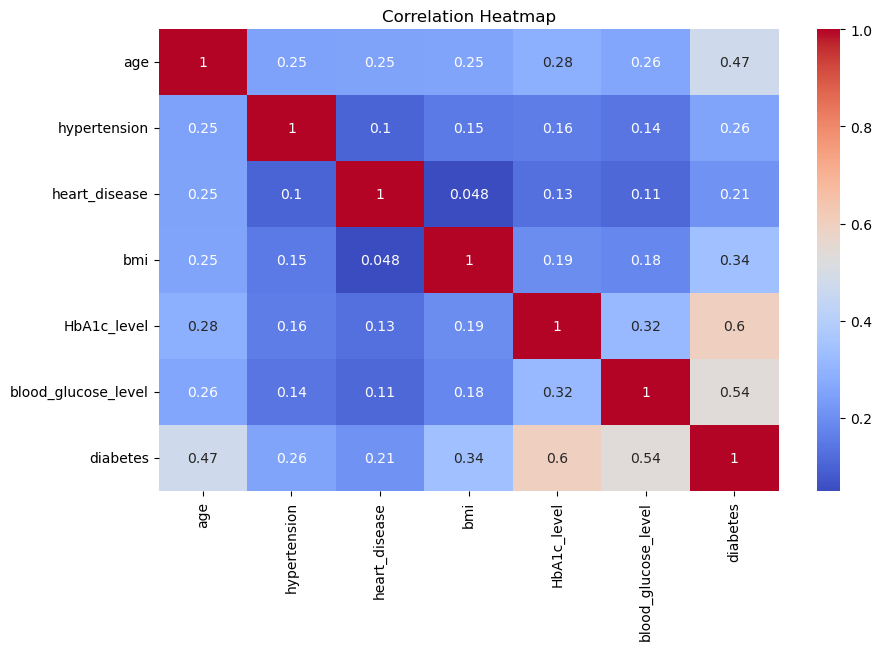

In [21]:
plt.figure(figsize=(10, 6))
correlation = newdiab.corr(numeric_only = True)
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [22]:
newdiab['gender'] = newdiab['gender'].map({'Male':1,'Female':0})

In [23]:
newdiab = pd.get_dummies(newdiab,columns=['smoking_history'])

In [24]:
newdiab.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
17453,1.0,8.0,0,0,16.34,6.5,126,0,False,False,False,False,True,False
27377,1.0,8.0,0,0,27.32,3.5,200,0,False,False,False,False,True,False
11938,1.0,19.0,0,0,24.51,6.2,155,0,True,False,False,False,False,False
82039,0.0,19.0,0,0,26.55,6.5,155,0,False,False,True,False,False,False
28293,0.0,42.0,0,0,20.91,4.0,85,0,True,False,False,False,False,False


In [25]:
newdiab = newdiab.dropna(subset=['gender'])

In [26]:
X = newdiab.drop(columns = "diabetes",axis=1)
Y = newdiab["diabetes"]

In [27]:
X

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
17453,1.0,8.0,0,0,16.34,6.5,126,False,False,False,False,True,False
27377,1.0,8.0,0,0,27.32,3.5,200,False,False,False,False,True,False
11938,1.0,19.0,0,0,24.51,6.2,155,True,False,False,False,False,False
82039,0.0,19.0,0,0,26.55,6.5,155,False,False,True,False,False,False
28293,0.0,42.0,0,0,20.91,4.0,85,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99935,0.0,65.0,1,1,33.55,8.2,140,False,False,False,False,True,False
99938,1.0,55.0,0,1,30.42,6.2,300,False,False,False,True,False,False
99957,0.0,61.0,0,0,34.45,6.5,280,True,False,False,False,False,False
99962,0.0,58.0,1,0,38.31,7.0,200,False,False,False,False,True,False


In [28]:
Y

17453    0
27377    0
11938    0
82039    0
28293    0
        ..
99935    1
99938    1
99957    1
99962    1
99979    1
Name: diabetes, Length: 16999, dtype: int64

In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [30]:
scaler = StandardScaler()

In [31]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
classifier = LogisticRegression(solver='liblinear',random_state=42)

In [33]:
classifier.fit(X_train_scaled,Y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [34]:
y_predlog = classifier.predict(X_test_scaled)

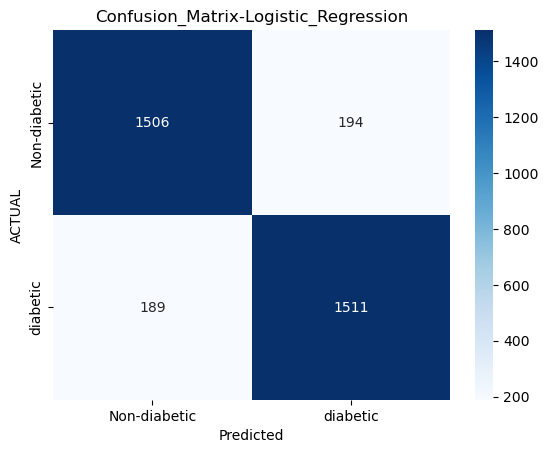

In [35]:
cm = confusion_matrix(Y_test,y_predlog)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Non-diabetic','diabetic'],yticklabels=['Non-diabetic','diabetic'])
plt.title("Confusion_Matrix-Logistic_Regression")
plt.ylabel("ACTUAL")
plt.xlabel("Predicted")
plt.show()

In [36]:
report = classification_report(Y_test,y_predlog)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1700
           1       0.89      0.89      0.89      1700

    accuracy                           0.89      3400
   macro avg       0.89      0.89      0.89      3400
weighted avg       0.89      0.89      0.89      3400



In [37]:
accuracy = accuracy_score(Y_test,y_predlog)

In [38]:
print(f"Accuracy:{accuracy:.2%}")

Accuracy:88.74%


In [39]:
import joblib
joblib.dump(classifier,"diabetes-prediction-model.pkl")
joblib.dump(scaler, "scaler.pkl") 

['scaler.pkl']

In [40]:
newpatient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)
newpatient_scaled = scaler.transform(newpatient)
prediction = classifier.predict(newpatient_scaled)
prediction_probability = classifier.predict_proba(newpatient_scaled)
if prediction[0] == 0:
    print("Patient is non diabetic")
else:
    print("Patient is diabetic")

print(f"Prediction confidence probability: non_diabetic:{prediction_probability[0][0]:.2%},diabetic:{prediction_probability[0][1]:.2%}")

Patient is diabetic
Prediction confidence probability: non_diabetic:19.03%,diabetic:80.97%


In [41]:
#Training the model on svc(support vector classification / support vector machine)
svm_model = SVC(kernel='rbf', probability=True)

svm_model.fit(X_train_scaled, Y_train)

SVC(probability=True)

In [42]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [43]:
svm_accuracy = accuracy_score(Y_test, y_pred_svm)

print(f"SVM Accuracy:{svm_accuracy:.2%}")

SVM Accuracy:89.00%


In [44]:
print("Classification Report (SVM):\n")

print(classification_report(Y_test, y_pred_svm))

Classification Report (SVM):

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1700
           1       0.88      0.90      0.89      1700

    accuracy                           0.89      3400
   macro avg       0.89      0.89      0.89      3400
weighted avg       0.89      0.89      0.89      3400



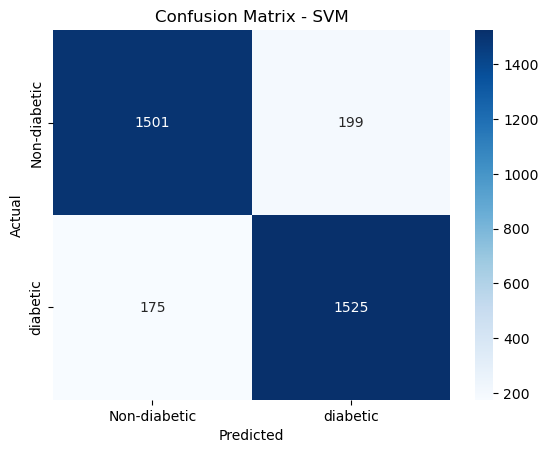

In [45]:
cm_svm = confusion_matrix(Y_test, y_pred_svm)

sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-diabetic','diabetic'],
            yticklabels=['Non-diabetic','diabetic'])

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
new_patient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)

new_patient_scaled = scaler.transform(new_patient)

svm_prediction = svm_model.predict(new_patient_scaled)
svm_probability = svm_model.predict_proba(new_patient_scaled)

if svm_prediction[0] == 0:
    print("The person is NOT diabetic (SVM)")
else:
    print("The person is DIABETIC (SVM)")
    
print("\nConfidence Probability:")
print(f"Non-diabetic: {svm_probability[0][0]*100:.2f}%")
print(f"Diabetic: {svm_probability[0][1]*100:.2f}%")

The person is DIABETIC (SVM)

Confidence Probability:
Non-diabetic: 14.76%
Diabetic: 85.24%


In [47]:
#   Training the Model with Randomforest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [48]:
rf_predictions = rf_model.predict(X_test)

In [49]:
rf_accuracy = accuracy_score(Y_test, rf_predictions)

print(f"Random Forest Accuracy:{rf_accuracy:.2%}")

Random Forest Accuracy:90.65%


In [50]:
print("Classification Report (Random Forest):\n")

print(classification_report(Y_test, rf_predictions))

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      1700
           1       0.90      0.92      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



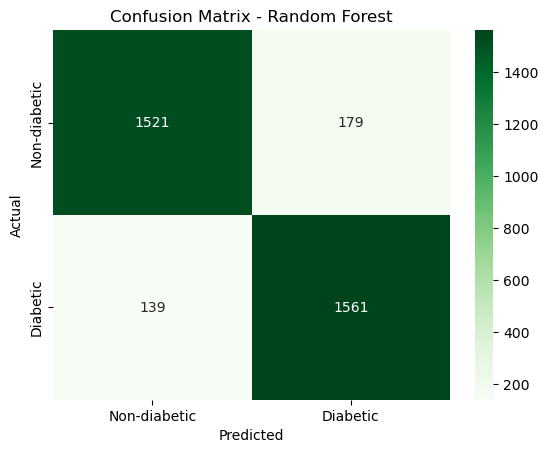

In [51]:
cm_rf = confusion_matrix(Y_test, rf_predictions)

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Non-diabetic','Diabetic'],
            yticklabels=['Non-diabetic','Diabetic'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
new_patient = pd.DataFrame([[1,45,1,0,29,6.5,160,False,False,False,True,False,False]],columns=X_train.columns)

rf_prediction  = rf_model.predict(new_patient)
rf_probability = rf_model.predict_proba(new_patient) 

if rf_prediction[0] == 0:
    print("The person is NOT diabetic (Random Forest)")
else:
    print("The person is DIABETIC (Random Forest)")

print("\nConfidence Probability:")
print(f"Non-diabetic: {rf_probability[0][0]*100:.2f}%")
print(f"Diabetic: {rf_probability[0][1]*100:.2f}%")

The person is NOT diabetic (Random Forest)

Confidence Probability:
Non-diabetic: 51.00%
Diabetic: 49.00%


In [53]:

lr_pred = classifier.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)


lr_acc = accuracy_score(Y_test, lr_pred)
svm_acc = accuracy_score(Y_test, svm_pred)
rf_acc = accuracy_score(Y_test, rf_pred)

print("Model Accuracy Comparison\n")

print(f"Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"SVM Accuracy                 : {svm_acc*100:.2f}%")
print(f"Random Forest Accuracy       : {rf_acc*100:.2f}%")


best_model = max(
    [("Logistic Regression", lr_acc),
     ("SVM", svm_acc),
     ("Random Forest", rf_acc)],
    key=lambda x: x[1]
)

print(f"\nBest Performing Model: {best_model[0]} ({best_model[1]*100:.2f}%)")

Model Accuracy Comparison

Logistic Regression Accuracy : 88.74%
SVM Accuracy                 : 89.00%
Random Forest Accuracy       : 90.65%

Best Performing Model: Random Forest (90.65%)


In [54]:
joblib.dump(svm_model, "svm-model.pkl")

['svm-model.pkl']

In [55]:
joblib.dump(rf_model, "random-forest-model.pkl")

['random-forest-model.pkl']

C:\Users\siddharth Tiwari\AppData\Local\Temp\ipykernel_22632\2036924955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


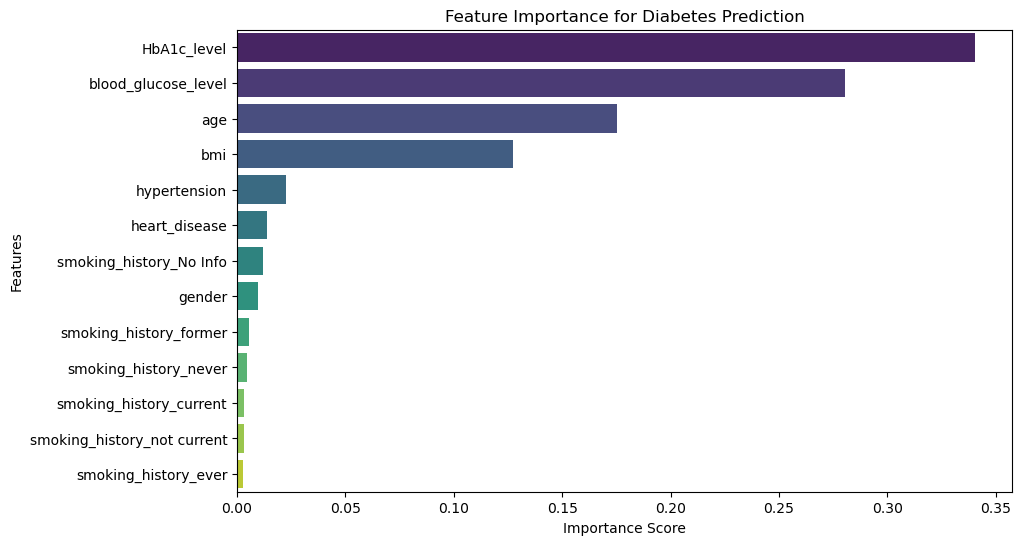

In [56]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Diabetes Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [57]:

print(newdiab.groupby('smoking_history_No Info')['age'].mean())


no_info_children = newdiab[(newdiab['smoking_history_No Info'] == True) & (newdiab['age'] < 18)].shape[0]
print(f"Number of children in No Info group: {no_info_children}")

smoking_history_No Info
False    54.208005
True     41.646771
Name: age, dtype: float64
Number of children in No Info group: 1244


c:\Users\siddharth Tiwari\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:56:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost ===
Accuracy : 0.9176
ROC-AUC  : 0.9809
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1700
           1       0.90      0.93      0.92      1700

    accuracy                           0.92      3400
   macro avg       0.92      0.92      0.92      3400
weighted avg       0.92      0.92      0.92      3400



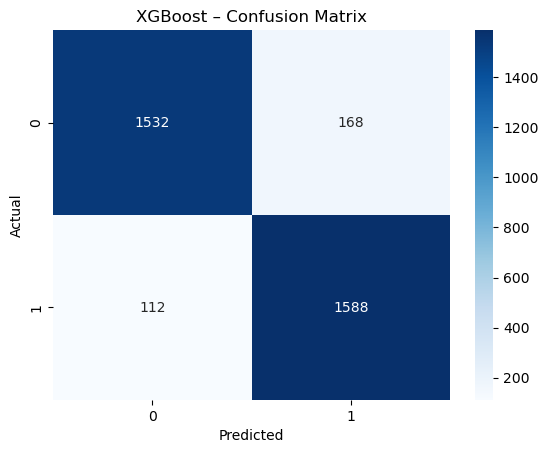

In [58]:
# ── XGBoost ──────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, Y_train)
xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost ===")
print(f"Accuracy : {accuracy_score(Y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")
print(classification_report(Y_test, xgb_pred))
sns.heatmap(confusion_matrix(Y_test, xgb_pred), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

=== CatBoost ===
Accuracy : 0.9144
ROC-AUC  : 0.9809
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      1700
           1       0.90      0.93      0.92      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



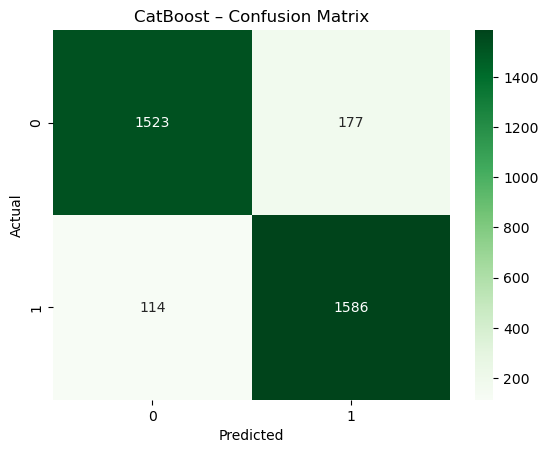

In [59]:
# ── CatBoost ─────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0,          # suppress training logs
    random_state=42
)
cat_model.fit(X_train, Y_train)
cat_pred = cat_model.predict(X_test)

print("=== CatBoost ===")
print(f"Accuracy : {accuracy_score(Y_test, cat_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, cat_model.predict_proba(X_test)[:,1]):.4f}")
print(classification_report(Y_test, cat_pred))
sns.heatmap(confusion_matrix(Y_test, cat_pred), annot=True, fmt='d', cmap='Greens')
plt.title('CatBoost – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

=== LightGBM ===
Accuracy : 0.9179
ROC-AUC  : 0.9808
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1700
           1       0.90      0.94      0.92      1700

    accuracy                           0.92      3400
   macro avg       0.92      0.92      0.92      3400
weighted avg       0.92      0.92      0.92      3400



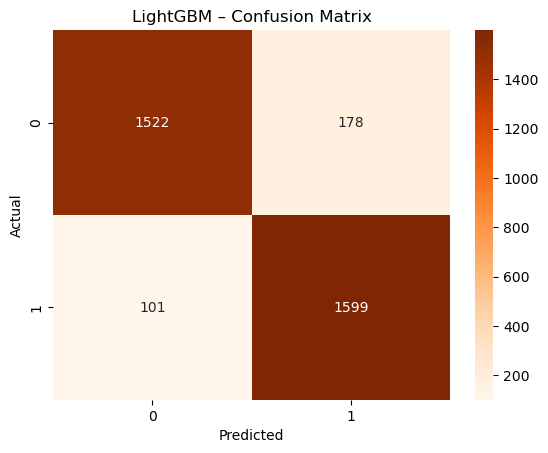

In [60]:
# ── LightGBM ─────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,          # shallower trees → fewer dead-end splits
    num_leaves=15,        # must be < 2^max_depth
    min_child_samples=20, # min data in a leaf, reduces overfitting
    verbose=-1,           # suppresses all [Info] and [Warning] logs
    random_state=42
)
lgbm_model.fit(X_train, Y_train)
lgbm_pred = lgbm_model.predict(X_test)

print("=== LightGBM ===")
print(f"Accuracy : {accuracy_score(Y_test, lgbm_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(Y_test, lgbm_model.predict_proba(X_test)[:,1]):.4f}")
print(classification_report(Y_test, lgbm_pred))
sns.heatmap(confusion_matrix(Y_test, lgbm_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('LightGBM – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

In [61]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 5, 6, 8],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5, 7],
    'gamma':           [0, 0.1, 0.2, 0.5],
    'reg_alpha':       [0, 0.01, 0.1, 1],
    'reg_lambda':      [1, 1.5, 2, 5],
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,           # tries 50 random combos
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1            # uses all CPU cores
)

random_search.fit(X_train, Y_train)

print("Best Params :", random_search.best_params_)
print("Best ROC-AUC:", round(random_search.best_score_, 4))
best_xgb_pred = random_search.best_estimator_.predict(X_test)
best_xgb_acc  = accuracy_score(Y_test, best_xgb_pred)
print(f"Best Accuracy: {best_xgb_acc:.4f}")
print()

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\siddharth Tiwari\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:57:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params : {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.7}
Best ROC-AUC: 0.9784
Best Accuracy: 0.9174



In [62]:
from sklearn.model_selection import GridSearchCV

# Narrow grid around best params from RandomizedSearchCV
param_grid = {
    'n_estimators':    [200, 300, 400],
    'max_depth':       [4, 5, 6],
    'learning_rate':   [0.05, 0.1, 0.15],
    'subsample':       [0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8, 0.9],
    'min_child_weight':[1, 3, 5],
}

xgb_base2 = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

grid_search = GridSearchCV(
    estimator=xgb_base2,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Params :", grid_search.best_params_)
print("Best ROC-AUC:", round(grid_search.best_score_, 4))
best_xgb_pred = grid_search.best_estimator_.predict(X_test)
best_xgb_acc  = accuracy_score(Y_test, best_xgb_pred)
print(f"Best Accuracy: {best_xgb_acc:.4f}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Params : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}
Best ROC-AUC: 0.9783
Best Accuracy: 0.9174


c:\Users\siddharth Tiwari\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:00:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [63]:
joblib.dump(xgb_model,    "xgboost_model.pkl")
joblib.dump(random_search.best_estimator_, "xgboost_tuned_model.pkl")
joblib.dump(cat_model,    "catboost_model.pkl")
joblib.dump(lgbm_model,   "lightgbm_model.pkl")

['lightgbm_model.pkl']

c:\Users\siddharth Tiwari\anaconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


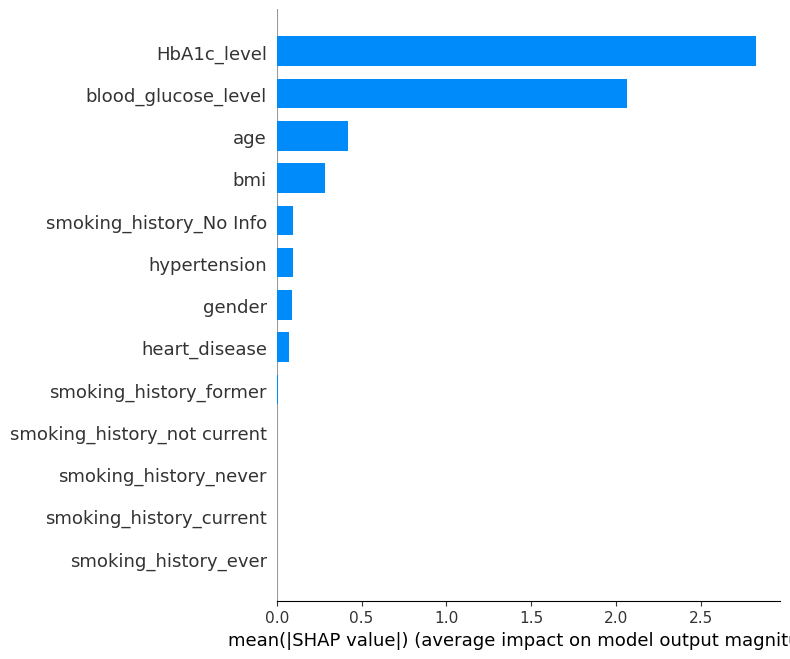

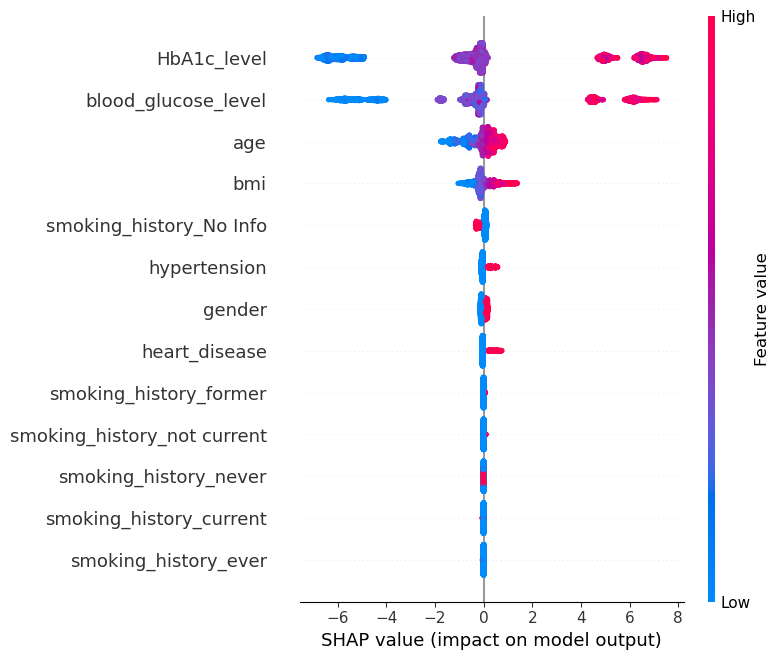

Actual: 1 | Predicted: 1


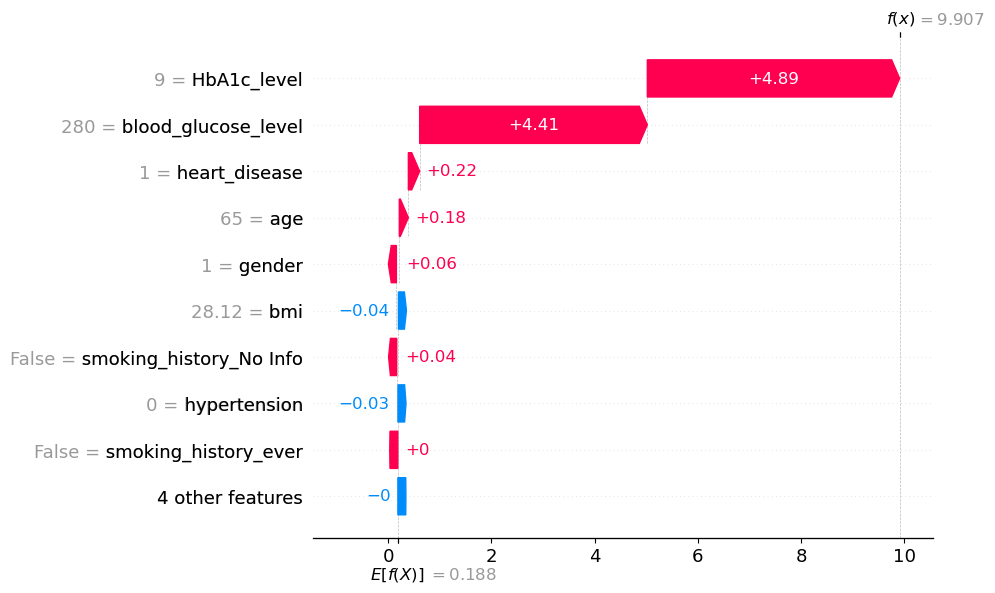

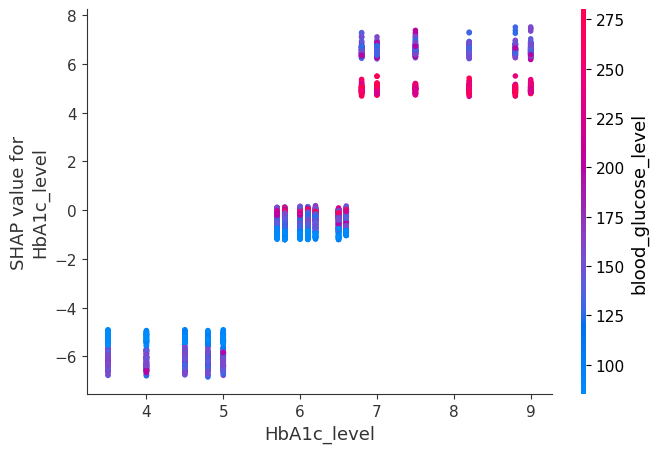

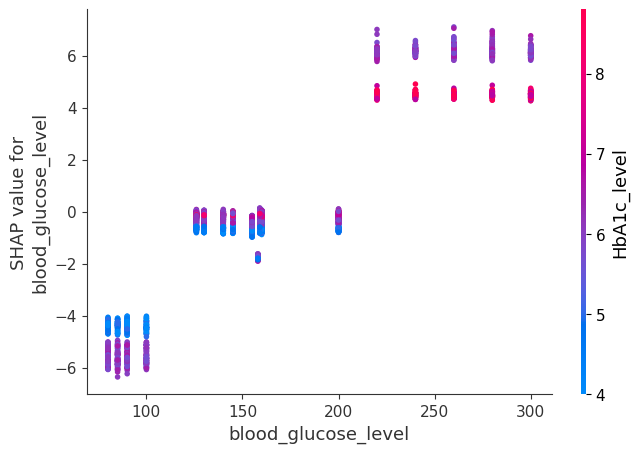

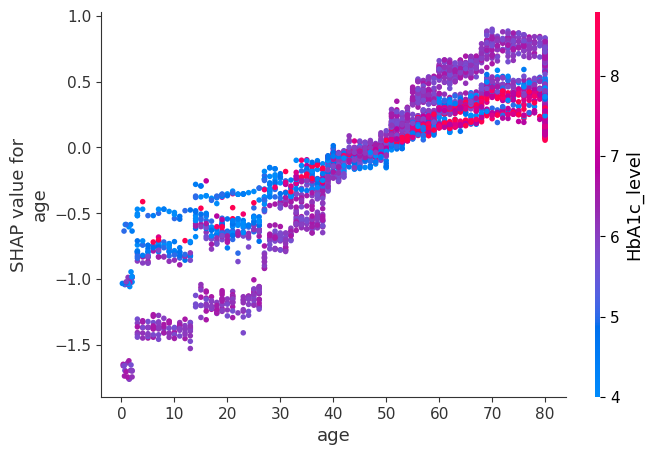

In [64]:

import shap
shap.initjs()

# ── Explainer ────────────────────────────────────────────
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

# LightGBM returns [class0, class1] — take class 1 (diabetic)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
explanation = explainer(X_test)
exp = explanation[:, :, 1] if explanation.values.ndim == 3 else explanation

# ── 1. Summary Bar — overall feature importance ──────────
shap.summary_plot(sv, X_test, plot_type="bar")

# ── 2. Beeswarm — direction + magnitude of impact ────────
shap.summary_plot(sv, X_test)

# ── 3. Waterfall — explain one individual patient ────────
i = 0  # change to any patient index
print(f"Actual: {Y_test.iloc[i]} | Predicted: {lgbm_model.predict(X_test)[i]}")
shap.plots.waterfall(exp[i])

# ── 4. Force Plot — compact single patient explanation ───
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    sv[i],
    X_test.iloc[i]
)

# ── 5. Dependence Plots — top 3 features ─────────────────
for feat in ['HbA1c_level', 'blood_glucose_level', 'age']:
    shap.dependence_plot(feat, sv, X_test)

Patient 0 → Actual: Diabetic | Predicted: Diabetic


c:\Users\siddharth Tiwari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


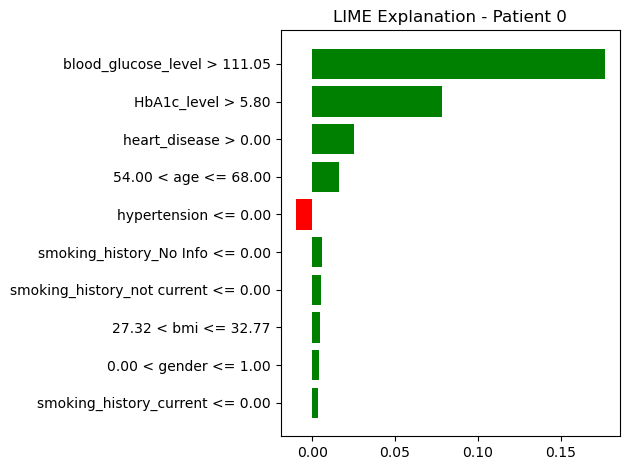


LIME Feature Contributions:
                       Feature Rule  Impact        Direction
       blood_glucose_level > 111.05  0.1764 🔴 Increases Risk
                 HbA1c_level > 5.80  0.0782 🔴 Increases Risk
               heart_disease > 0.00  0.0252 🔴 Increases Risk
               54.00 < age <= 68.00  0.0163 🔴 Increases Risk
               hypertension <= 0.00 -0.0098 🟢 Decreases Risk
    smoking_history_No Info <= 0.00  0.0060 🔴 Increases Risk
smoking_history_not current <= 0.00  0.0054 🔴 Increases Risk
               27.32 < bmi <= 32.77  0.0047 🔴 Increases Risk
              0.00 < gender <= 1.00  0.0043 🔴 Increases Risk
    smoking_history_current <= 0.00  0.0034 🔴 Increases Risk


In [68]:
import lime
from lime.lime_tabular import LimeTabularExplainer

def get_background_data(X_train, n_samples=500):
    """
    Generates a realistic background dataset for LIME.
    Constrains clinical ranges to the healthy population baseline 
    while preserving the categorical representations (e.g., one-hot encodings).
    """
    # Sample from the training data directly to preserve realistic joint distributions
    bg = X_train.sample(n=n_samples, replace=True, random_state=42).copy()
    
    # Constrain continuous markers to non-diabetic/healthy ranges
    bg['blood_glucose_level'] = np.random.uniform(70, 125, size=n_samples)
    bg['HbA1c_level'] = np.random.uniform(4.0, 6.4, size=n_samples)
    
    # Smoking and other one-hot categorical columns are left unchanged
    return bg

# Initialize the explainer using the constrained background dataset
explainer_lime = LimeTabularExplainer(
    training_data=get_background_data(X_train).values,
    feature_names=X_train.columns.tolist(),
    class_names=['Non-Diabetic', 'Diabetic'],
    mode='classification',
    random_state=42
)

# Run and display the LIME instance explanation
i = 0  
lime_exp = explainer_lime.explain_instance(
    X_test.iloc[i].values,
    lgbm_model.predict_proba,
    num_features=10
)

print(f"Patient {i} → Actual: {'Diabetic' if Y_test.iloc[i]==1 else 'Non-Diabetic'} "
      f"| Predicted: {'Diabetic' if lgbm_model.predict(X_test)[i]==1 else 'Non-Diabetic'}")

import matplotlib.pyplot as plt
import pandas as pd

lime_exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Patient {i}")
plt.tight_layout()
plt.show()

lime_df = pd.DataFrame(lime_exp.as_list(), columns=['Feature Rule', 'Impact'])
lime_df['Direction'] = lime_df['Impact'].apply(lambda x: '🔴 Increases Risk' if x > 0 else '🟢 Decreases Risk')
lime_df['Impact'] = lime_df['Impact'].round(4)

print("\nLIME Feature Contributions:")
print(lime_df.to_string(index=False))